### В данном уроке мы выделим еще несколько потенциально важных фичей из изначального датасета и попробуем применить изученные методы отбора признаков к итоговому датасету.

In [1]:
import numpy as np
import pandas as pd

processed_data = pd.read_csv('processed_data.csv', index_col='id')

processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration
id,,,,,
id2875421,1,930.399753,0,1.500479,6.122493
id2377394,0,930.399753,0,1.807119,6.498282
id3858529,1,930.399753,0,6.392080,7.661527
id3504673,1,930.399753,0,1.487155,6.063785
id2181028,1,930.399753,0,1.189925,6.077642


In [2]:
initial_data = pd.read_csv('taxi_dataset.csv')

initial_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N


In [3]:
initial_data.shape[0] == processed_data.shape[0]

True

In [4]:
### Вернем в датасет колонку pickup_datetime

initial_data = initial_data.set_index('id')

processed_data = pd.merge(processed_data, initial_data['pickup_datetime'],
                          left_index=True, right_index=True)

In [5]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,pickup_datetime
id,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,2016-03-14 17:24:55
id2377394,0,930.399753,0,1.807119,6.498282,2016-06-12 00:43:35
id3858529,1,930.399753,0,6.392080,7.661527,2016-01-19 11:35:24
id3504673,1,930.399753,0,1.487155,6.063785,2016-04-06 19:32:31
id2181028,1,930.399753,0,1.189925,6.077642,2016-03-26 13:30:55


Напомним, **pickup_datetime** - время начала поездки.

Кажется, что в зависимости от месяца/дня недели/времени суток движение на дорогах может отличаться. Как из-за погодных условий, так и из-за загруженности транспорта. Поэтому, есть подозрение, что будет полезно выделить ряд признаков из колонки **pickup_datetime**. Давайте исследуем зависимость нашей таргетной переменной от указанных факторов.

In [6]:
processed_data['pickup_datetime'] = pd.to_datetime(processed_data['pickup_datetime'])

processed_data['date'] = processed_data.pickup_datetime.dt.date
processed_data['day_of_week'] = processed_data.pickup_datetime.dt.dayofweek
processed_data['hour'] = processed_data.pickup_datetime.dt.hour
processed_data['month'] = processed_data.pickup_datetime.dt.month

In [7]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,pickup_datetime,date,day_of_week,hour,month
id,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,2016-03-14 17:24:55,2016-03-14,0,17,3
id2377394,0,930.399753,0,1.807119,6.498282,2016-06-12 00:43:35,2016-06-12,6,0,6
id3858529,1,930.399753,0,6.392080,7.661527,2016-01-19 11:35:24,2016-01-19,1,11,1
id3504673,1,930.399753,0,1.487155,6.063785,2016-04-06 19:32:31,2016-04-06,2,19,4
id2181028,1,930.399753,0,1.189925,6.077642,2016-03-26 13:30:55,2016-03-26,5,13,3


Исследуем, когда и сколько поездок было совершено. 

Начнем с графиков, показывающих количество поездок в зависимости от времени суток/даты и т.д.

Так же полезно сразу показать и среднее значение таргетной переменной.

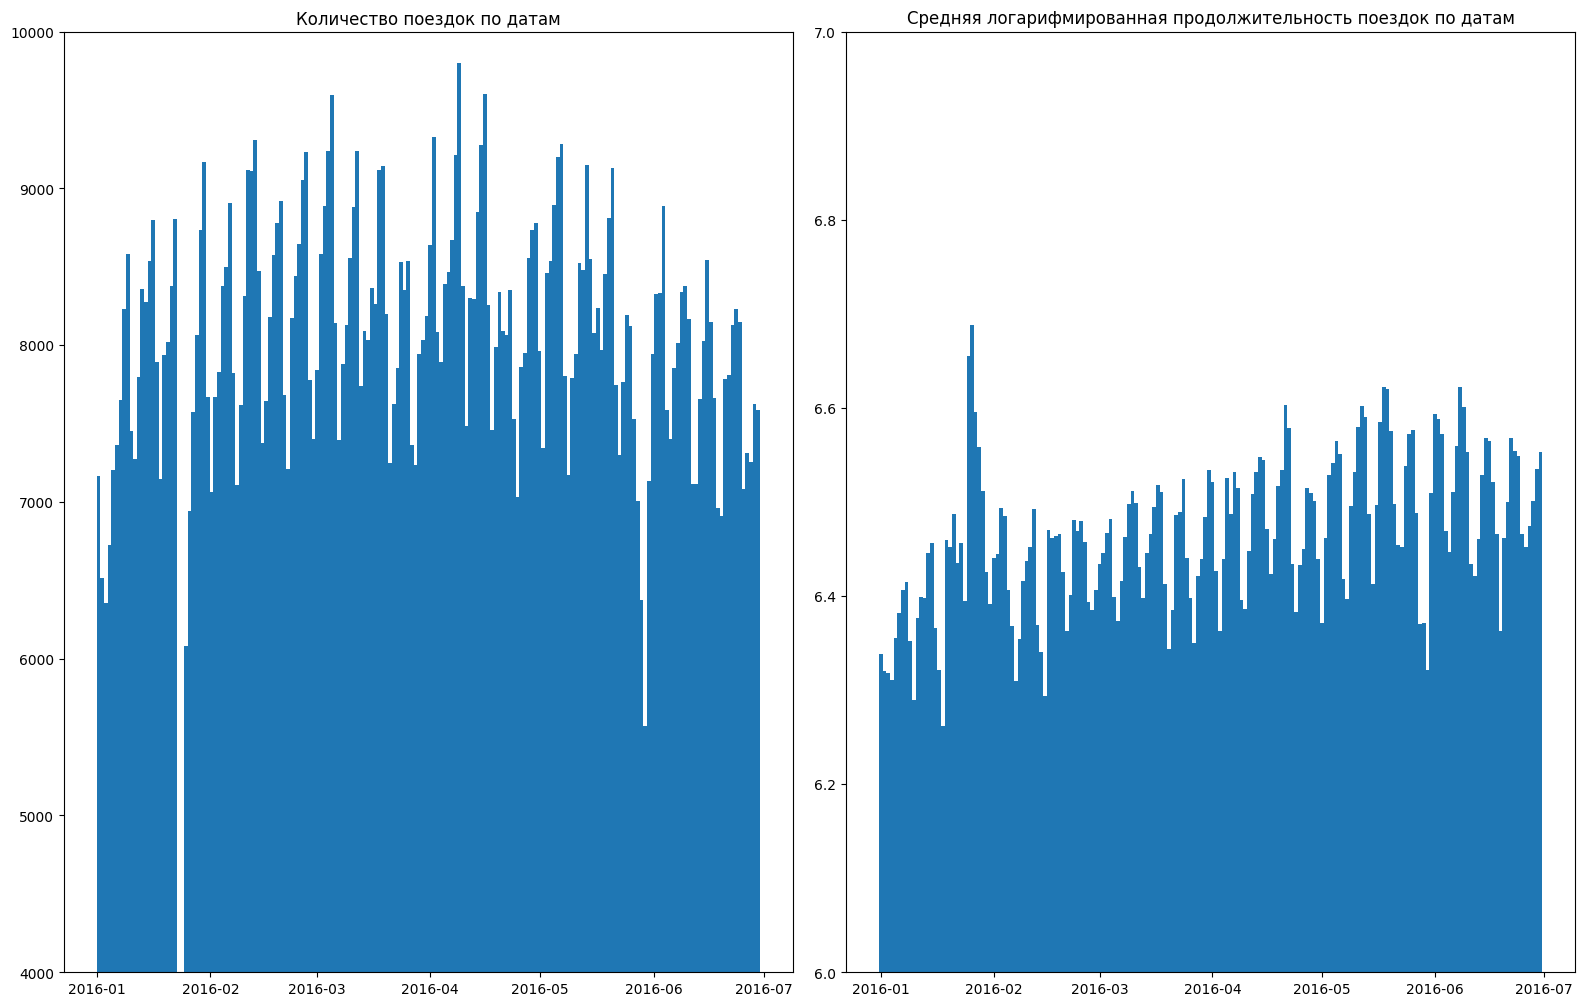

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure()

fig.set_size_inches(16, 10)

ax_1 = fig.add_subplot(1, 2, 1)
plt.hist(processed_data['date'], bins=processed_data.date.unique().shape[0])
plt.ylim((4000, 10000))

ax_2 = fig.add_subplot(1, 2, 2)
plt.bar(sorted(list(processed_data['date'].unique())), 
        processed_data.groupby('date', as_index=False)['log_trip_duration'].mean()['log_trip_duration'],
        width=1)
plt.ylim((6, 7))

fig.tight_layout()

ax_1.set(title = 'Количество поездок по датам')
ax_2.set(title = 'Средняя логарифмированная продолжительность поездок по датам')

plt.show()

Кажется, что внутри недели есть некоторая зависимость таргета от дня недели. 

Такая же зависимость может оказаться и внутри дня (в завимости от часов).

Предлагаю исследовать эту зависимость подробнее.

Изобразите следующие графики зависимостей:

- Количество поездок/Средняя продолжительность поездки vs День недели
- Количество поездок/Средняя продолжительность поездки vs время суток
- Средняя продолжительность поездки vs время суток для каждого дня недели (например, нарисовав с разными цветами и, соответственно, легендами)
- Аналогичные графики, используя информацию о месяце, внутри которого была совершена поездка.
- Ящики с усами для различных: времени суток, дня недели, месяца

Используйте любые доступные инструменты pyplot!

Далее, на основе полученных результатов, мы будем принимать решение о создании новых признаков.

EDA можно использовать не только для того, чтобы понять, какие фичи можно убрать из датасета. Но и для выделения базовых признаков. Этим и займемся!

P.S. Сами графики мы проверять у Вас не будем. Зато для ответа на устные вопросы понадобятся, поэтому, в любом случае, крайне рекомендуем поупражняться. Поэтому рисовать все графики не обязательно - ограничьтесь теми, которые помогут Вам ответить на тестовые вопросы.

**Hint**: обратите внимание на сильную просадку в январе. Почему она могла произойти - можно прочитать <a href="https://en.wikipedia.org/wiki/January_2016_United_States_blizzard"> здесь</a>. В будущем можно будет создать бинарный признак "произошла ли поездка во время сильного снегопада".


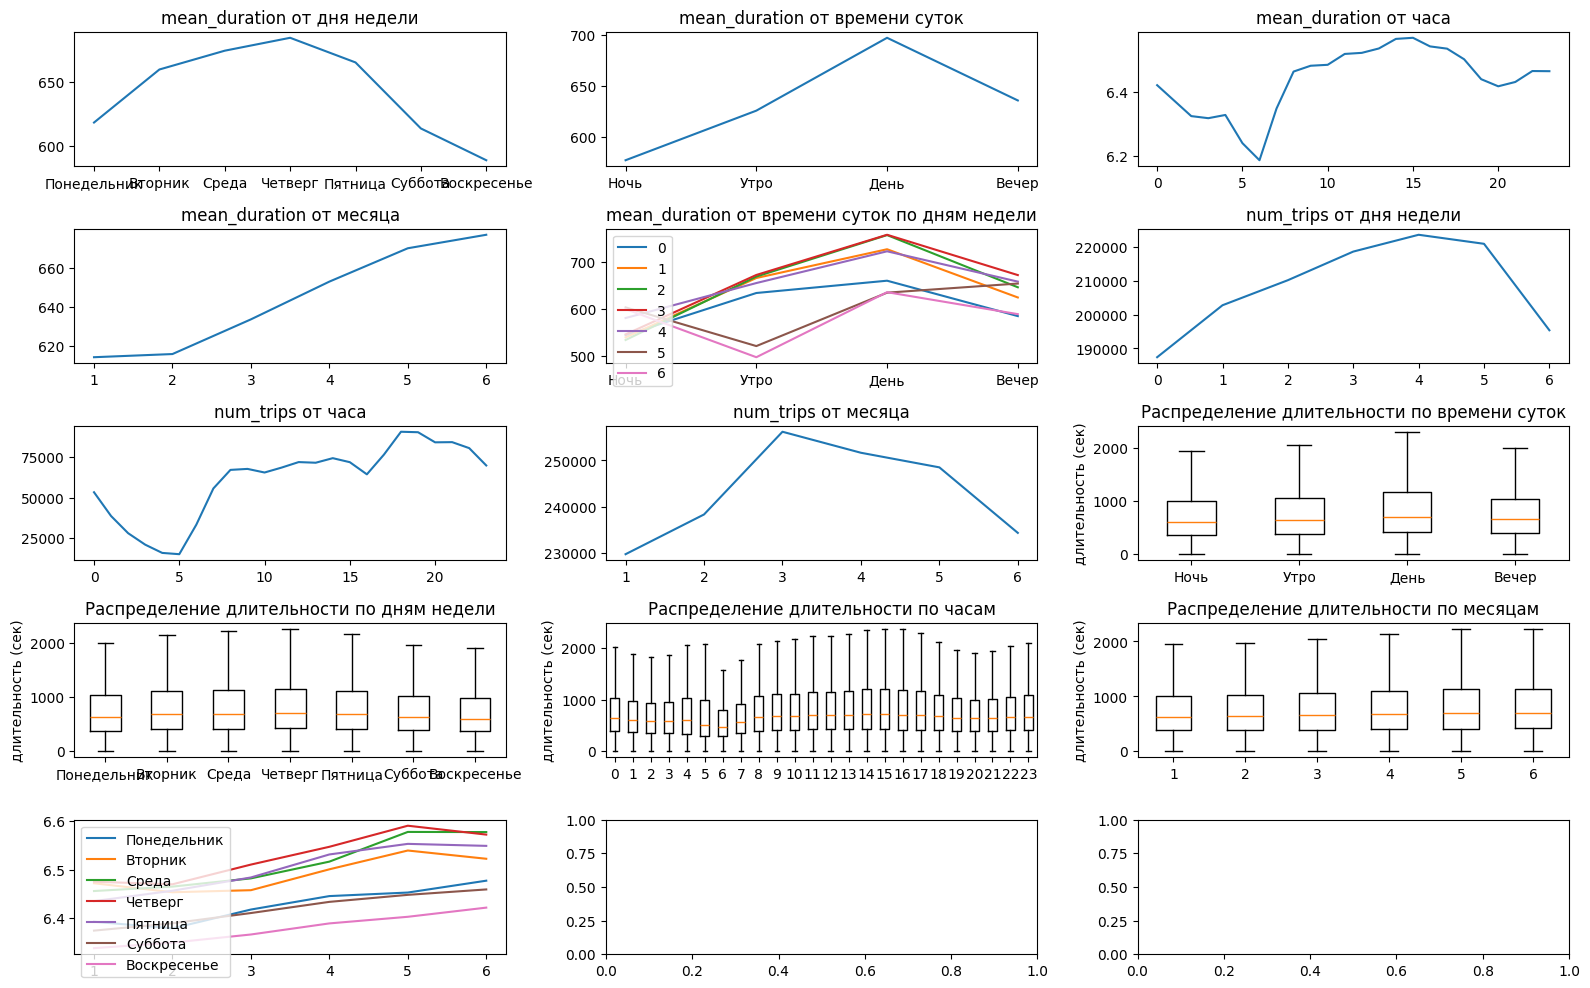

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# График зависимости средней продолжительности поездки от дня недели
# ============================================================
grouped_by_day_of_week = processed_data[['log_trip_duration', 'day_of_week']].groupby('day_of_week')
mean_duration = grouped_by_day_of_week.mean()
mean_duration.reset_index(inplace=True)

days_of_week = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']

fig, axes = plt.subplots(5, 3, figsize=(16, 10))

x = [days_of_week[x] for x in mean_duration['day_of_week'].to_numpy()]
y = [np.exp(x) for x in mean_duration['log_trip_duration'].to_numpy()]
axes[0, 0].plot(x, y)
axes[0, 0].set_title('mean_duration от дня недели')

# ============================================================
# График зависимости средней продолжительности поездки от времени суток
# ============================================================
bins = [0, 6, 12, 18, 24]
labels = ['Ночь', 'Утро', 'День', 'Вечер']
processed_data['time_of_day'] = pd.cut(processed_data['hour'], bins=bins, labels=labels, right=False)

grouped_by_time_of_day = processed_data[['log_trip_duration', 'time_of_day']].groupby('time_of_day')
mean_duration = grouped_by_time_of_day.mean()
mean_duration.reset_index(inplace=True)

x = labels
y = [np.exp(x) for x in mean_duration['log_trip_duration'].to_numpy()]
axes[0, 1].plot(x, y)
axes[0, 1].set_title('mean_duration от времени суток')

# ============================================================
# График зависимости средней продолжительности поездки от часа
# ============================================================
grouped_by_hour = processed_data[['log_trip_duration', 'hour']].groupby('hour')
mean_duration = grouped_by_hour.mean().reset_index()

x = mean_duration['hour'].to_numpy()
y = mean_duration['log_trip_duration'].to_numpy()

axes[0, 2].plot(x, y)
axes[0, 2].set_title('mean_duration от часа')

# ============================================================
# График зависимости средней продолжительности поездки от месяца
# ============================================================
grouped_by_month = processed_data.groupby('month')['log_trip_duration']
mean_duration = grouped_by_month.mean().reset_index()

x = mean_duration['month'].to_numpy()
y = [np.exp(x) for x in mean_duration['log_trip_duration'].to_numpy()]

axes[1, 0].plot(x, y)
axes[1, 0].set_title('mean_duration от месяца')

# ============================================================
# График зависимости средней продолжительности поездки от времени суток по дням недели
# ============================================================
grouped = processed_data.groupby(['day_of_week', 'time_of_day'])['log_trip_duration'].mean().reset_index()
pivot_table = grouped.pivot(index='time_of_day', columns='day_of_week', values='log_trip_duration')

for day_of_week in pivot_table.columns:
    axes[1, 1].plot(pivot_table.index.to_numpy(), np.exp(pivot_table.loc[:, day_of_week]), label=day_of_week)
    
axes[1, 1].legend(loc='upper left')
axes[1, 1].set_title('mean_duration от времени суток по дням недели')

# ============================================================
# График количества поездок от дня недели
# ============================================================
grouped_by_day_of_week = processed_data.groupby('day_of_week')
num_trips = grouped_by_day_of_week['day_of_week'].count()

x = num_trips.index.to_numpy()
y = num_trips.to_numpy()

axes[1, 2].plot(x, y)
axes[1, 2].set_title('num_trips от дня недели')

# ============================================================
# График количества поездок от часа
# ============================================================
grouped_by_hour = processed_data.groupby('hour')
num_trips = grouped_by_hour['hour'].count()

x = num_trips.index.to_numpy()
y = num_trips.to_numpy()

axes[2, 0].plot(x, y)
axes[2, 0].set_title('num_trips от часа')

# ============================================================
# График количества поездок от месяца
# ============================================================
grouped_by_month = processed_data.groupby('month')
num_trips = grouped_by_month['month'].count()

x = num_trips.index.to_numpy()
y = num_trips.to_numpy()

axes[2, 1].plot(x, y)
axes[2, 1].set_title('num_trips от месяца')

# ============================================================
# Ящик с усами (boxplot) по времени суток
# ============================================================
data_box_log = [processed_data[processed_data['time_of_day'] == t]['log_trip_duration'].apply(np.exp).dropna() for t in labels]
axes[2, 2].boxplot(data_box_log, tick_labels=labels, showfliers=False)
axes[2, 2].set_ylabel('длительность (сек)')
axes[2, 2].set_title('Распределение длительности по времени суток')

# ============================================================
# Ящик с усами (boxplot) по дням недели
# ============================================================
day_codes = list(range(7))
data_sec = [processed_data[processed_data['day_of_week'] == code]['log_trip_duration'].apply(np.exp).dropna() for code in day_codes]
axes[3, 0].boxplot(data_sec, tick_labels=days_of_week, showfliers=False)
axes[3, 0].set_ylabel('длительность (сек)')
axes[3, 0].set_title('Распределение длительности по дням недели')

# ============================================================
# Ящик с усами (boxplot) по часам
# ============================================================
hour_codes = list(range(24))
data = [processed_data[processed_data['hour'] == code]['log_trip_duration'].apply(np.exp) for code in hour_codes]
axes[3, 1].boxplot(data, tick_labels=hour_codes, showfliers=False)
axes[3, 1].set_ylabel('длительность (сек)')
# Для часов префикс hour, постфикс от 1 до 23. Для дней недели day_of_week, от 1 до 
axes[3, 1].set_title('Распределение длительности по часам')

# ============================================================
# Ящик с усами (boxplot) по месяцам
# ============================================================
month_codes = list(range(1, 7))
data = [processed_data[processed_data['month'] == code]['log_trip_duration'].apply(np.exp) for code in month_codes]
axes[3, 2].boxplot(data, tick_labels=month_codes, showfliers=False)
axes[3, 2].set_ylabel('длительность (сек)')
axes[3, 2].set_title('Распределение длительности по месяцам')

# ============================================================
# График зависимости средней продолжительности поездки от месяца по дням недели
# ============================================================
grouped = processed_data[['day_of_week', 'month', 'log_trip_duration']].groupby(['day_of_week', 'month'])['log_trip_duration'].mean().reset_index()
p = grouped.pivot(index='day_of_week', columns='month', values='log_trip_duration')
x = p.columns
for d in p.index:
    axes[4, 0].plot(x, p.loc[d].to_numpy(), label=days_of_week[d])
    axes[4, 0].legend(loc='upper left')
    
fig.tight_layout()
plt.show()


Кажется, что полученные выводы из графиков выше достаточны для того, чтобы посчитать признаки, связанные с временем/датой поездки, достаточно важными. На их основе выделим еще пару.

Добавьте следующие бинарные признаки:


1. Была ли в день поездки буря (основываясь на единственном обнаруженном таком дне)
2. Является ли время поездки статистически самым проблемным, то есть час пиком?

Для создания 2ой фичи используйте следующую логику: посчитаем для каждой пары "день недели"-"время суток" среднее значение таргета. Найдем топ-10 самых "больших" пар. Если поездка была совершена во входящее в этот топ время, то ставим 1. Иначе - 0. Получается бинарный признак.

P.S. назовите колонки **anomaly** и **traffic_jam**

In [10]:
### Создадим первый бинарный признак

anomaly_date = '2016-01-23'
print(f"Дата аномалии: {anomaly_date}")

# Создаём бинарный признак
processed_data['anomaly'] = (processed_data['date'] == anomaly_date).astype(int)



Дата аномалии: 2016-01-23


In [11]:
### Создадим второй бинарный признак

grouped = processed_data.groupby(['day_of_week', 'hour'])['log_trip_duration'].mean().reset_index()
top10 = grouped.nlargest(10, 'log_trip_duration')  # топ-10 пар
# Создаём множество пар
top10_pairs = set(zip(top10['day_of_week'], top10['hour']))
# Применяем признак: 1 если пара в топ-10, иначе 0
processed_data['traffic_jam'] = processed_data.apply(
    lambda row: 1 if (row['day_of_week'], row['hour']) in top10_pairs else 0,
    axis=1
)

processed_data.drop('time_of_day', axis=1, inplace=True, errors='ignore')


In [12]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,pickup_datetime,date,day_of_week,hour,month,anomaly,traffic_jam
id,,,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,2016-03-14 17:24:55,2016-03-14,0,17,3,0,0
id2377394,0,930.399753,0,1.807119,6.498282,2016-06-12 00:43:35,2016-06-12,6,0,6,0,0
id3858529,1,930.399753,0,6.392080,7.661527,2016-01-19 11:35:24,2016-01-19,1,11,1,0,1
id3504673,1,930.399753,0,1.487155,6.063785,2016-04-06 19:32:31,2016-04-06,2,19,4,0,0
id2181028,1,930.399753,0,1.189925,6.077642,2016-03-26 13:30:55,2016-03-26,5,13,3,0,0


Теперь колонки **pickup_datetime**, **date** можно убрать. А про оставшиеся **day_of_week**, **hour**, **month** необходимо подумать:

- С одной стороны, первые две можно убрать, так как на их основе была создана колонка **traffic_jam**
- С другой стороны, зависимость с колонкой **traffic_jam** нелинейная, поэтому можно попробовать использовать все фичи в комбинации. Конечно, лучше попробовать оба варианта и проэкспериментировать, но ради упрощения - оставим все колонки. Хоть **day_of_week**, **hour** и описываются числами, мы понимаем, что это скорее категориальные фичи. Потому что, например, отношение между 23:00 и 00:00 не такое же, как между числами 23 и 0. Закодируем их с помощью OneHotEncoder. 
- Последняя (**month**) очевидно категориальная. Можно закодировать ее тоже через OneHotEncoder.

In [13]:
n_trips = processed_data.groupby('date')['log_trip_duration'].count()
trip_duration = processed_data[['date', 'log_trip_duration']].groupby('date').mean()['log_trip_duration']

print(n_trips, trip_duration)

print(n_trips.corr(trip_duration))

processed_data = processed_data.drop(['pickup_datetime', 'date'], axis=1)

date
2016-01-01    7162
2016-01-02    6512
2016-01-03    6353
2016-01-04    6725
2016-01-05    7204
              ... 
2016-06-26    7084
2016-06-27    7311
2016-06-28    7253
2016-06-29    7623
2016-06-30    7588
Name: log_trip_duration, Length: 182, dtype: int64 date
2016-01-01    6.338735
2016-01-02    6.320602
2016-01-03    6.317985
2016-01-04    6.310565
2016-01-05    6.355708
                ...   
2016-06-26    6.452000
2016-06-27    6.474596
2016-06-28    6.500996
2016-06-29    6.534773
2016-06-30    6.552577
Name: log_trip_duration, Length: 182, dtype: float64
0.1939027899956656


In [14]:
### Делаем OneHotEncoding и конкатим с processed_data

for col in ['day_of_week', 'hour', 'month']:
    dummies = pd.get_dummies(processed_data[col], prefix=col, drop_first=True)
    processed_data = pd.concat([processed_data, dummies], axis='columns')

processed_data.drop(['day_of_week', 'hour', 'month'], axis='columns', inplace=True)

processed_data = processed_data.apply(
    lambda x: x.astype('int8') if x.dtype == 'bool' else x
)

processed_data.head(5).to_csv('output.csv')

Что же, мы с Вами научились с помощью EDA визуализаций понимать важность признаков не только постфактум, но и до того, как сформировался финальный датасет - на этапе **выделения базовых фичей**.

Обратимся теперь к методам фильтрации - например, применим корреляционный анализ для одной пары фичей, чтобы понять, нет ли относительно этих колонок в нашем датасете избытка информации. 

Вспомним так же изначальные вещественные признаки - distance_km, passenger_count

Посчитайте корреляцию между ними. Есть ли какие-то основания для беспокойства?

In [15]:
processed_data.drop(['time_of_day'], axis=1, inplace=True, errors='ignore')
print(processed_data.corr(), processed_data.corr().loc['distance_km', 'passenger_count'])
processed_data.drop('n_trips', axis=1, inplace=True, errors='ignore')


                    vendor_id  passenger_count  store_and_fwd_flag  \
vendor_id            1.000000         0.258422           -0.079872   
passenger_count      0.258422         1.000000           -0.018487   
store_and_fwd_flag  -0.079872        -0.018487            1.000000   
distance_km          0.008107         0.016596            0.026275   
log_trip_duration    0.019720         0.027069            0.015326   
anomaly                   NaN              NaN                 NaN   
traffic_jam         -0.003243        -0.007711            0.006137   
day_of_week_1        0.001714        -0.014537           -0.000167   
day_of_week_2       -0.001434        -0.015004            0.000923   
day_of_week_3       -0.001472        -0.013064            0.002295   
day_of_week_4       -0.001465        -0.001282            0.001185   
day_of_week_5        0.000378         0.030807           -0.003103   
day_of_week_6        0.002930         0.023559           -0.003384   
hour_1              

In [16]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,anomaly,traffic_jam,day_of_week_1,day_of_week_2,day_of_week_3,...,hour_19,hour_20,hour_21,hour_22,hour_23,month_2,month_3,month_4,month_5,month_6
id,,,,,,,,,,,,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
id2377394,0,930.399753,0,1.807119,6.498282,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
id3858529,1,930.399753,0,6.392080,7.661527,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
id3504673,1,930.399753,0,1.487155,6.063785,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
id2181028,1,930.399753,0,1.189925,6.077642,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [17]:
### На данный момент у нас 41 фича
### Представим, что хочется сократить их количество до 5.
### Воспользуемся для этим каким-нибудь методом обертки
### Например, метод прямого отбора

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

X = processed_data.drop(['log_trip_duration', 'time_of_day'], axis=1, errors='ignore')
print(X.columns.tolist())

y = processed_data['log_trip_duration']
model = LinearRegression()

selected = []          # отобранные признаки
remaining = list(X.columns)   # кандидаты

for step in range(5):
    best_score = -np.inf
    best_feature = None
    
    for feature in remaining:
        current_set = selected + [feature]
        scores = cross_val_score(model, X[current_set], y, cv=None, scoring='neg_mean_squared_error')
        mean_score = scores.mean()
        
        if mean_score > best_score:
            best_score = mean_score
            best_feature = feature
    
    if best_feature is not None:
        selected.append(best_feature)
        remaining.remove(best_feature)
        print(f"Шаг {step+1}: добавлен '{best_feature}', neg_MSE = {best_score:.4f}")
    else:
        break
    

['vendor_id', 'passenger_count', 'store_and_fwd_flag', 'distance_km', 'anomaly', 'traffic_jam', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6', 'hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6']
Шаг 1: добавлен 'distance_km', neg_MSE = -0.4275
Шаг 2: добавлен 'hour_6', neg_MSE = -0.4246
Шаг 3: добавлен 'traffic_jam', neg_MSE = -0.4221
Шаг 4: добавлен 'hour_5', neg_MSE = -0.4202
Шаг 5: добавлен 'day_of_week_6', neg_MSE = -0.4183


In [ ]:
### Тот же код, но через sklearn

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X = processed_data.drop(['log_trip_duration', 'time_of_day'], axis=1, errors='ignore')
y = processed_data['log_trip_duration']
model = LinearRegression()

# Forward selection на 5 признаков
sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=9,
    direction='forward',       # forward selection (как у вас)
    scoring='neg_mean_squared_error',
    cv=None,
    n_jobs=-1
)

sfs.fit(X, y)

selected_features = X.columns[sfs.get_support()].tolist()
print("Отобранные признаки:", selected_features)

In [ ]:
### Перечислите фичи, которые окажутся наиболее желанными
print("Отобранные признаки:", selected)

In [18]:
### Представим, что мы с Вами ничего не знаем про Кросс-Валидацию и отложенную выборку
### Замерьте качество линейной регрессии на данных фичах
### Сильно ли оно отличается от полученного на Кросс-Валидации в прошлом уроке в ДЗ?
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(processed_data[selected], processed_data['log_trip_duration'])
pred = model.predict(processed_data[selected])
mse = np.mean((pred - processed_data['log_trip_duration'].to_numpy()) ** 2)
print(mse)


0.41540002340782556


In [ ]:
# Отличается не сильно.